# Mutual Fund Analytics - Exploratory Data Analysis

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the Mutual Fund Analytics dataset.

The objectives are:

- Analyze NAV trends
- Analyze AUM growth
- Study SIP inflows
- Analyze investor demographics
- Analyze folio growth
- Study sector allocation
- Identify important business insights

Author: Praneesh

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [4]:
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [5]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [6]:
datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Investor": investor,
    "Holding": holding,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Investor: (32778, 13)
Holding: (322, 8)
Benchmark: (8050, 3)


In [7]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.head())

Fund Master
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumps

## Data Inspection
We inspect the datasets to understand:
- Column names
- Data types
- Missing values
- Memory usage

In [20]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print(df.info())

NameError: name 'datasets' is not defined

In [ ]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print(df.isnull().sum())

Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64
NAV
amfi_code    0
date         0
nav          0
dtype: int64
AUM
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64
SIP
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64
Category
month               0
category            0
net_inflow_crore    0
dtype: int64
Folio
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_f

In [ ]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Fund Master: 0 duplicate rows
NAV: 0 duplicate rows
AUM: 0 duplicate rows
SIP: 0 duplicate rows
Category: 0 duplicate rows
Folio: 0 duplicate rows
Performance: 0 duplicate rows
Investor: 0 duplicate rows
Holding: 0 duplicate rows
Benchmark: 0 duplicate rows


In [ ]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print(df.dtypes)
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print(df.describe())

Fund Master
amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object
NAV
amfi_code      int64
date          object
nav          float64
dtype: object
AUM
date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object
SIP
month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object
Category
month                object
category          

In [ ]:
print(nav.columns.tolist())
nav.head(10)
nav.info()

['amfi_code', 'date', 'nav']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [ ]:
print(fund_master.columns.tolist())
nav_merged = pd.merge(
    nav,
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)
nav_merged.head()
nav_merged["date"] = pd.to_datetime(nav_merged["date"])
nav_merged.info()

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   amfi_code    46000 non-null  int64         
 1   date         46000 non-null  datetime64[ns]
 2   nav          46000 non-null  float64       
 3   scheme_name  46000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.4+ MB


In [ ]:
print(nav_merged["date"].min())
print(nav_merged["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [ ]:
fig = px.line(
    nav_merged,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "scheme_name": "Scheme"
    },
    template="plotly_white",
    width=1200,
    height=700
)

fig.update_layout(
    width=1400,
    height=800,

    legend=dict(
        title="Scheme Name",
        orientation="v",
        y=1,
        yanchor="top",
        x=1.02,
        xanchor="left",
        font=dict(size=8)
    ),

    margin=dict(r=300)
)
fig.update_xaxes(
    tickangle=-45
)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="Correction"
)
fig.update_traces(
    hovertemplate="<b>%{fullData.name}</b><br>Date: %{x}<br>NAV: ₹%{y:.2f}<extra></extra>"
)
fig.show()

In [ ]:
print("Unique Schemes:", nav_merged["scheme_name"].nunique())

print("\nUnique AMFI Codes in Fund Master:")
print(fund_master["amfi_code"].nunique())

print("\nUnique AMFI Codes in NAV:")
print(nav["amfi_code"].nunique())

print("\nNAV Count per Scheme:")
print(nav_merged.groupby("scheme_name")["nav"].count())

print("\nNAV Statistics per Scheme:")
print(nav_merged.groupby("scheme_name")["nav"].describe())

Unique Schemes: 40

Unique AMFI Codes in Fund Master:
40

Unique AMFI Codes in NAV:
40

NAV Count per Scheme:
scheme_name
ABSL Frontline Equity Fund - Regular - Growth            1150
ABSL Liquid Fund - Regular - Growth                      1150
ABSL Small Cap Fund - Regular - Growth                   1150
Axis Bluechip Fund - Direct - Growth                     1150
Axis Bluechip Fund - Regular - Growth                    1150
Axis Midcap Fund - Regular - Growth                      1150
Axis Small Cap Fund - Regular - Growth                   1150
DSP Midcap Fund - Regular - Growth                       1150
DSP Small Cap Fund - Regular - Growth                    1150
DSP Top 100 Equity Fund - Regular - Growth               1150
HDFC Mid-Cap Opportunities Fund - Direct - Growth        1150
HDFC Mid-Cap Opportunities Fund - Regular - Growth       1150
HDFC Short Term Debt Fund - Regular - Growth             1150
HDFC Top 100 Fund - Direct Plan - Growth                 1150
HDFC Top 1

In [ ]:
nav_merged.head(20)
nav_merged.sample(20)

,amfi_code,date,nav,scheme_name
29121,119093,2023-06-06,33.6197,Axis Bluechip Fund - Direct - Growth
17696,118632,2023-09-19,72.5851,Nippon India Large Cap Fund - Regular - Growth
5735,119120,2026-05-11,54.4266,SBI Magnum Gilt Fund - Regular Plan - Growth
45063,149324,2022-10-27,84.6096,DSP Small Cap Fund - Regular - Growth
44080,149323,2023-06-19,126.5972,DSP Midcap Fund - Regular - Growth
35519,101208,2025-11-28,396.1134,ABSL Liquid Fund - Regular - Growth
20284,118634,2024-10-25,109.6753,Nippon India Small Cap Fund - Regular - Growth
16186,120507,2022-05-03,292.5851,ICICI Pru Liquid Fund - Regular - Growth
23068,120841,2022-04-07,263.9590,Kotak Bluechip Fund - Regular - Growth
37426,102886,2024-05-28,142.9667,UTI Mid Cap Fund - Regular - Growth


In [ ]:
scheme = nav_merged["scheme_name"].iloc[0]

nav_merged[nav_merged["scheme_name"] == scheme].head(10)

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth
5,119551,2022-01-10,55.2835,SBI Bluechip Fund - Regular Plan - Growth
6,119551,2022-01-11,56.0878,SBI Bluechip Fund - Regular Plan - Growth
7,119551,2022-01-12,56.4978,SBI Bluechip Fund - Regular Plan - Growth
8,119551,2022-01-13,56.2934,SBI Bluechip Fund - Regular Plan - Growth
9,119551,2022-01-14,56.5926,SBI Bluechip Fund - Regular Plan - Growth


In [ ]:
aum.head()
print(aum.columns.tolist())
aum.info()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


In [ ]:
aum["date"] = pd.to_datetime(aum["date"])
aum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[ns]
 1   fund_house      90 non-null     object        
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 3.6+ KB


In [ ]:
aum["year"] = aum["date"].dt.year
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [ ]:
print(aum["year"].unique())

[2022 2023 2024 2025]


FileNotFoundError: [Errno 2] No such file or directory: 'charts/aum_growth.png'

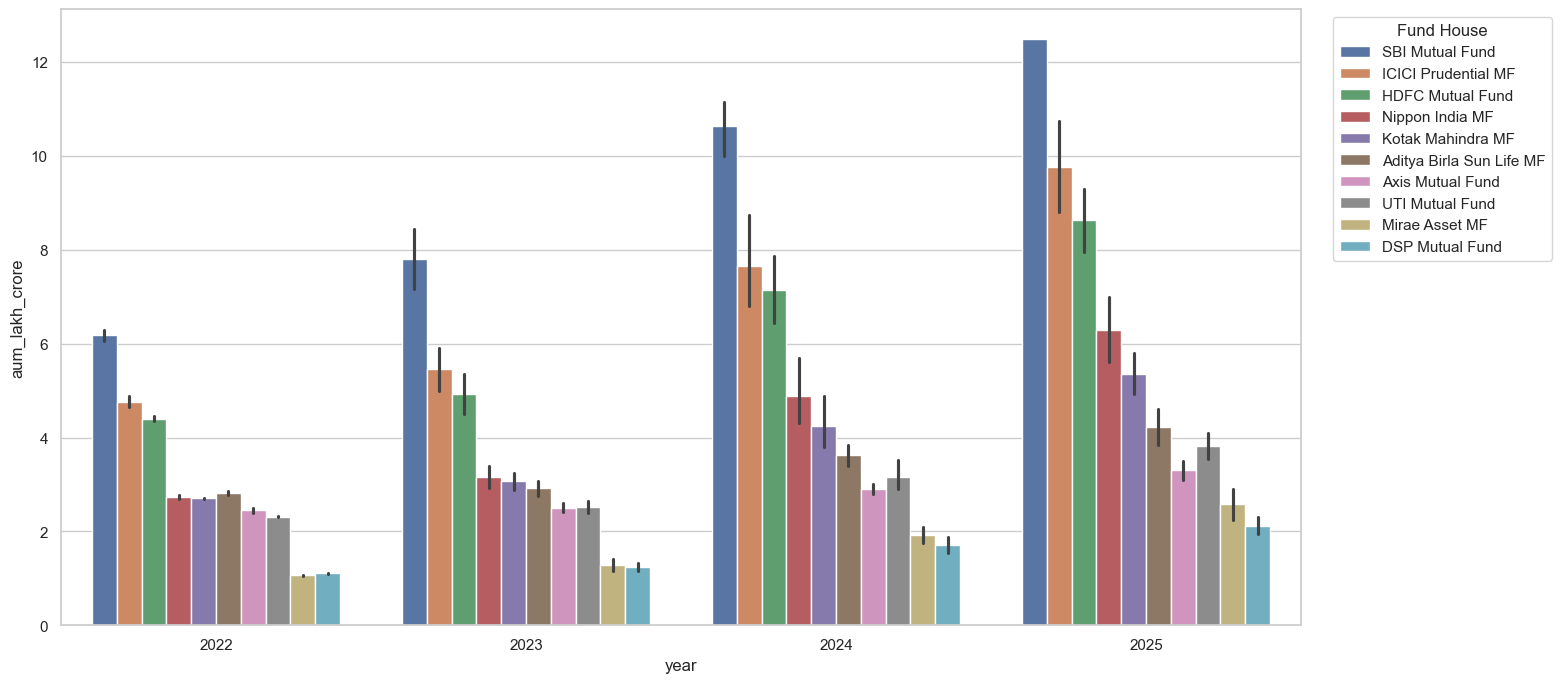

In [ ]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=0)


plt.show()

In [ ]:
aum.sort_values(
    by="aum_lakh_crore",
    ascending=False
).head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216,2025
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195,2025
71,2025-03-31,ICICI Prudential MF,8.80,880000,216,2025
61,2024-12-31,ICICI Prudential MF,8.74,874000,216,2024
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023


In [ ]:
plt.savefig(
    "../charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
import os

print(os.getcwd())

c:\Users\praneesh\MutualFundAnalytics\notebooks


In [ ]:
import os

os.makedirs("../charts", exist_ok=True)

print("Current directory:", os.getcwd())
print("Charts folder exists:", os.path.exists("../charts"))

Current directory: c:\Users\praneesh\MutualFundAnalytics\notebooks
Charts folder exists: True


In [ ]:
fig = plt.gcf()   # Get Current Figure

plt.savefig(
    "../charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Chart saved successfully!")

<Figure size 640x480 with 0 Axes>

Chart saved successfully!


In [ ]:
sip.head()
print(sip.columns.tolist())
sip.info()

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
sip["month"] = pd.to_datetime(sip["month"])

sip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[ns]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 2.4 KB


In [ ]:
print("Start:", sip["month"].min())
print("End:", sip["month"].max())

Start: 2022-01-01 00:00:00
End: 2025-12-01 00:00:00


In [ ]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [ ]:
sip_plot = sip.copy()

sip_plot["month"] = sip_plot["month"].dt.strftime("%Y-%m")

In [ ]:
fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    template="plotly_white",
    width=1200,
    height=600
)

In [ ]:
max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True
)

In [ ]:
fig.write_image("../charts/sip_inflow_trend.png")

In [ ]:
fig2 = px.line(
    x=[1, 2, 3],
    y=[10, 20, 15],
    title="Test"
)

fig2.write_image("../charts/test.png")

In [ ]:
sip_plot = sip.copy()

# Convert datetime to string
sip_plot["month"] = sip_plot["month"].dt.strftime("%b %Y")

In [ ]:
fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    template="plotly_white",
    width=1200,
    height=600
)

max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)

fig.write_image("../charts/sip_inflow_trend.png")
fig.show()

In [ ]:
sip_plot = sip.copy()

sip_plot["month"] = sip_plot["month"].dt.strftime("%b %Y")

In [ ]:
sip_plot.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,Jan 2022,11517,4.91,9.10,4.80,NaN
1,Feb 2022,11438,4.93,8.20,4.85,NaN
2,Mar 2022,12328,5.09,10.50,5.01,NaN
3,Apr 2022,11863,5.48,9.52,5.12,NaN
4,May 2022,12286,5.55,8.10,5.15,NaN


In [ ]:
fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    template="plotly_white"
)

max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="<b>All-Time High</b><br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)
fig.update_xaxes(
    tickmode="array",
    tickvals=sip_plot["month"][::3]
)
fig.update_yaxes(showgrid=True)
fig.write_image("../charts/sip_inflow_trend.png")
fig.show()

### Chart 3: Monthly SIP Inflow Trend (2022–2025)

**Objective**

Analyze the monthly trend in Systematic Investment Plan (SIP) inflows.

**Business Insight**

Monthly SIP inflows increased steadily throughout the analysis period, reaching an all-time high in December 2025. This reflects increasing investor participation and growing confidence in long-term wealth creation through mutual funds.

In [ ]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

In [ ]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")
holding = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [ ]:
print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Holding:", holding.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Holding: (322, 8)


In [ ]:
category.head()
print(category.columns.tolist())
category.info()

['month', 'category', 'net_inflow_crore']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


In [ ]:
category["month"] = pd.to_datetime(category["month"])
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   month             144 non-null    datetime64[ns]
 1   category          144 non-null    object        
 2   net_inflow_crore  144 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 3.5+ KB


In [ ]:
category["month_label"] = category["month"].dt.strftime("%b %Y")

In [ ]:
heatmap_data = category.pivot(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

heatmap_data.head()

month_label,Apr 2024,Aug 2024,Dec 2024,Feb 2025,Jan 2025,Jul 2024,Jun 2024,Mar 2025,May 2024,Nov 2024,Oct 2024,Sep 2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


In [ ]:
heatmap_data = category.pivot(
    index="category",
    columns="month_label",
    values="net_inflow_crore"
)

heatmap_data.head()

month_label,Apr 2024,Aug 2024,Dec 2024,Feb 2025,Jan 2025,Jul 2024,Jun 2024,Mar 2025,May 2024,Nov 2024,Oct 2024,Sep 2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


In [ ]:
plt.savefig(
    "../charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

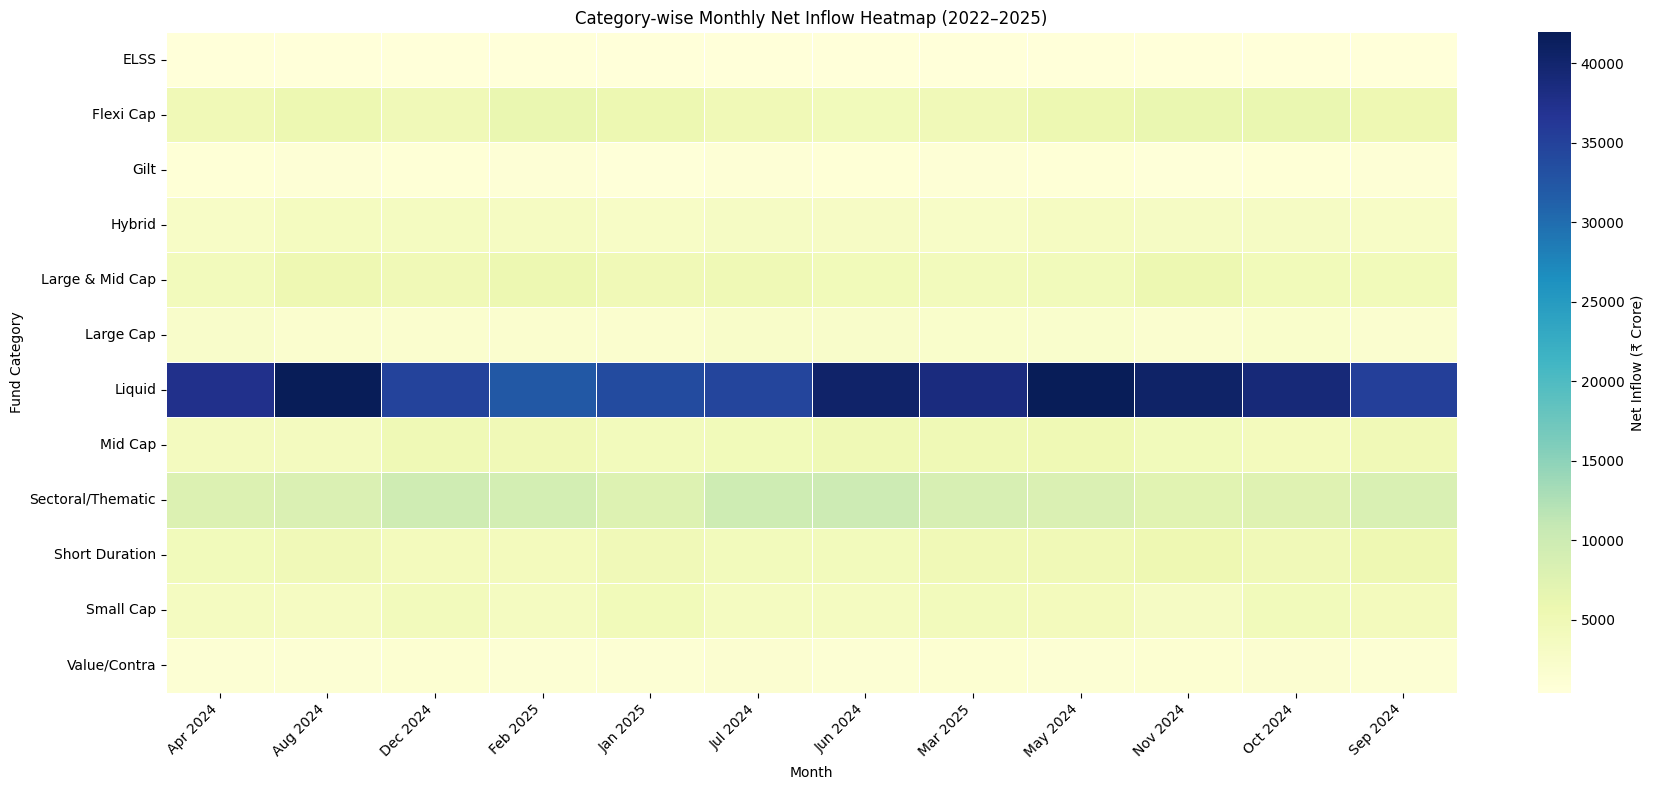

In [ ]:
plt.figure(figsize=(18, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title("Category-wise Monthly Net Inflow Heatmap (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 4: Category-wise Net Inflow Heatmap (2022–2025)

**Objective**

Visualize monthly net inflows across different mutual fund categories.

**Business Insight**

The heatmap highlights periods of strong and weak investor interest across fund categories. Darker shades indicate higher net inflows, helping identify seasonal patterns and categories that consistently attracted investments during the study period.

In [ ]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


In [ ]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [ ]:
age_counts = transactions["age_group"].value_counts()

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

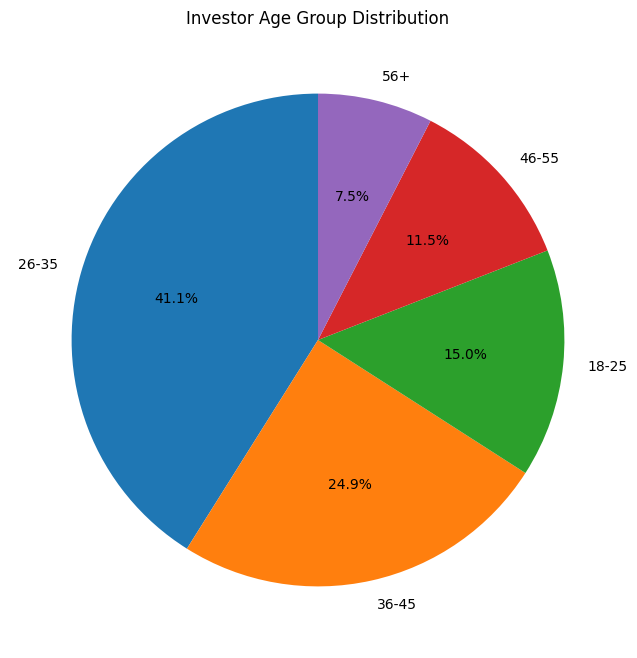

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 5.1: Investor Age Group Distribution

**Objective**

Understand the distribution of investors across different age groups.

**Business Insight**

The majority of investors belong to the working-age population, indicating that salaried individuals form the largest segment of mutual fund investors.

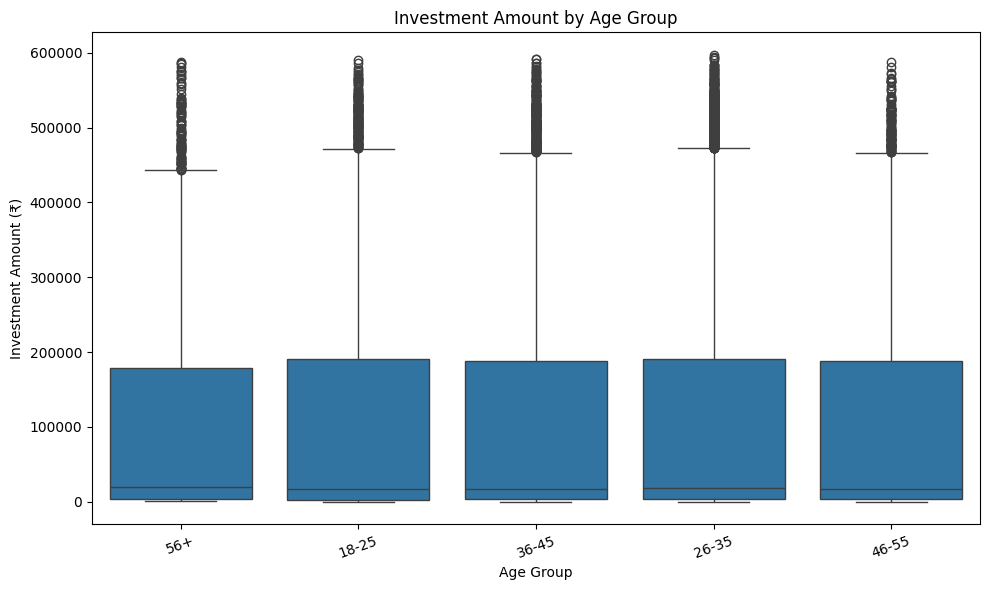

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../charts/sip_boxplot_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 5.2: Investment Amount by Age Group

**Objective**

Compare the distribution of investment amounts across different age groups.

**Business Insight**

Investment amounts vary across all age groups, with every group showing several high-value outliers. The 26–35 and 36–45 age groups display slightly wider investment ranges, indicating more diverse investment behaviour.

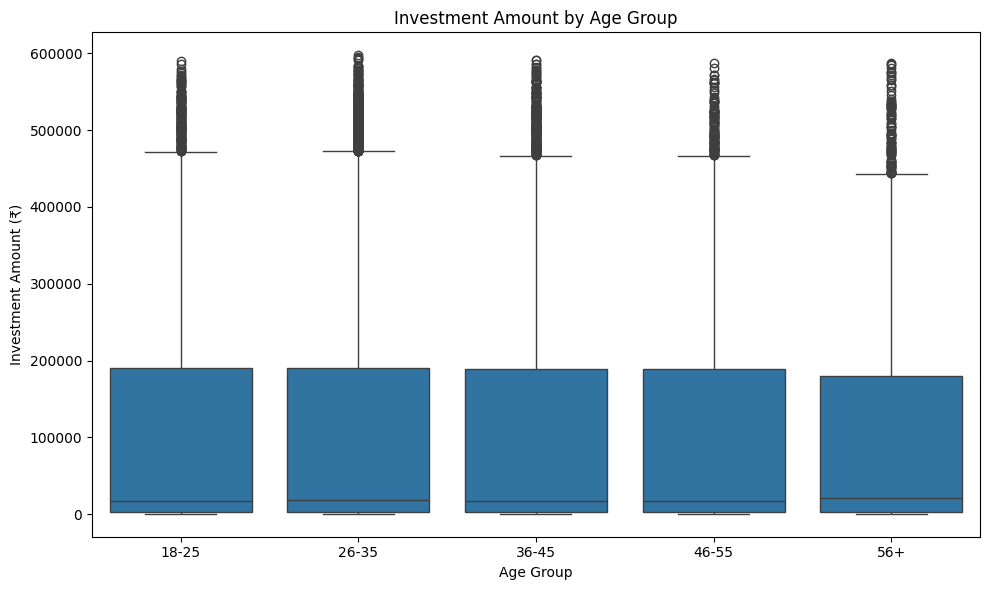

In [22]:
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr",
    order=age_order
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../charts/sip_boxplot_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

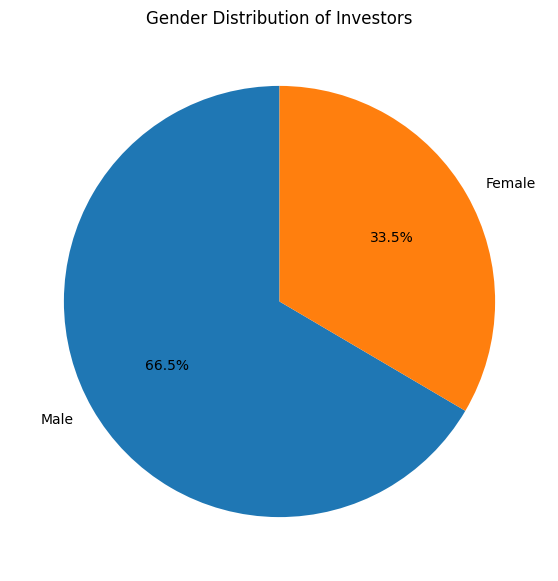

In [23]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig(
    "../charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 5.3: Gender Distribution of Investors

**Objective**

Analyze the gender composition of mutual fund investors.

**Business Insight**

Male investors account for **66.5%** of the investor base, while female investors represent **33.5%**. This suggests higher participation from male investors and indicates an opportunity to increase financial inclusion and investment awareness among women.

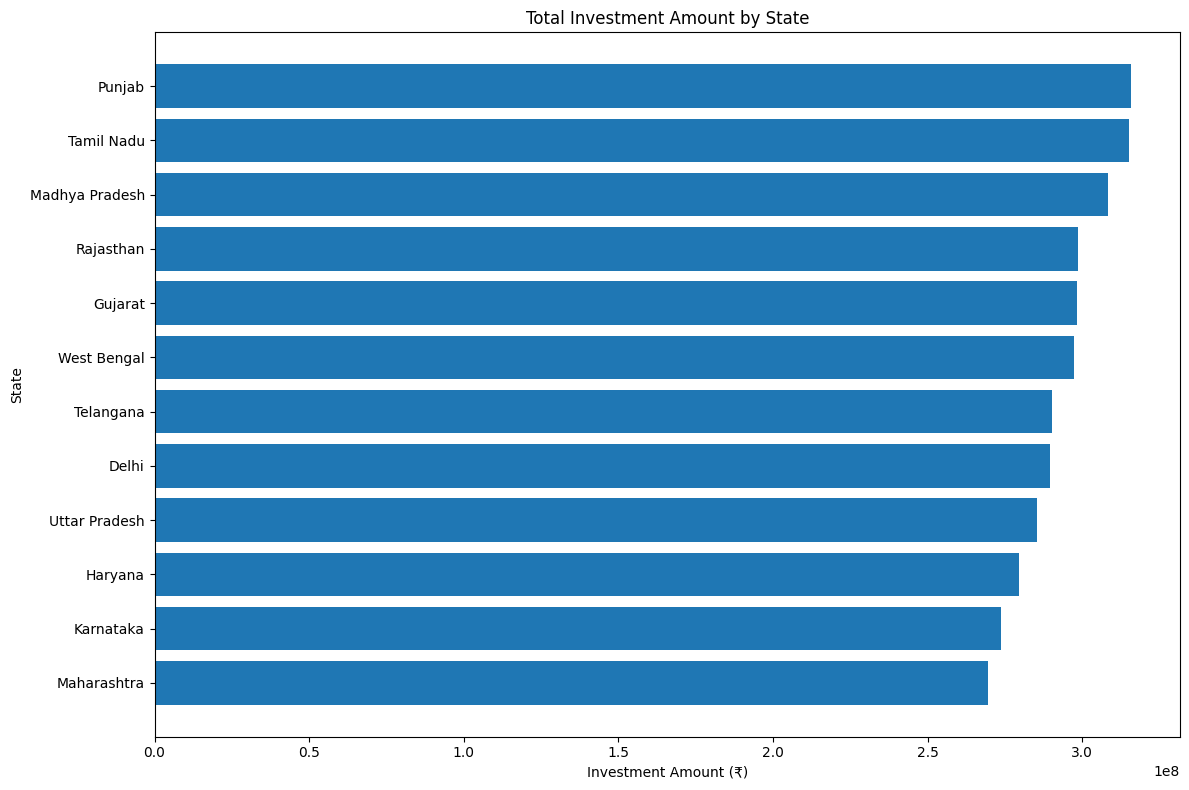

In [24]:
state_investment = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

plt.barh(
    state_investment.index,
    state_investment.values
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../charts/state_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 6.1: State-wise Total Investment Amount

**Objective**

Analyze the distribution of investment amounts across different states.

**Business Insight**

Punjab recorded the highest total investment amount in the dataset, while Maharashtra contributed the least among the selected states. Overall, investment activity is distributed across multiple states, indicating broad regional participation in mutual fund investments.

In [25]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

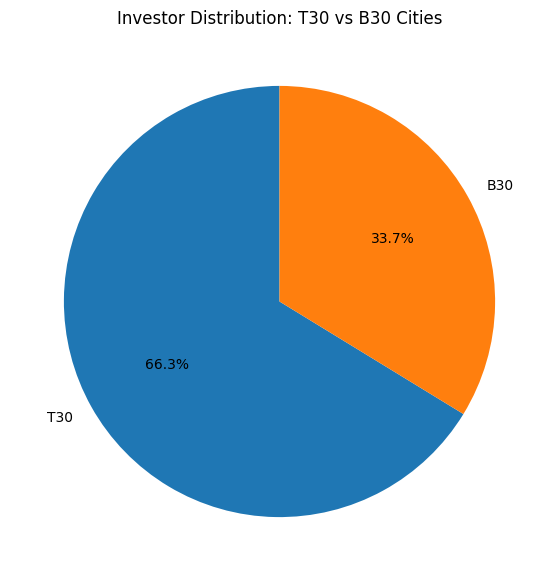

In [26]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30 Cities")

plt.savefig(
    "../charts/city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 6.2: T30 vs B30 City Tier Distribution

**Objective**

Compare investor participation between T30 and B30 cities.

**Business Insight**

The distribution highlights the contribution of investors from metro (T30) and emerging (B30) cities. This helps evaluate the reach of mutual fund investments beyond major metropolitan regions.

In [27]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [28]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [29]:
folio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [30]:
folio["month"] = pd.to_datetime(folio["month"])

folio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                21 non-null     datetime64[ns]
 1   total_folios_crore   21 non-null     float64       
 2   equity_folios_crore  21 non-null     float64       
 3   debt_folios_crore    21 non-null     float64       
 4   hybrid_folios_crore  21 non-null     float64       
 5   others_folios_crore  21 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.1 KB


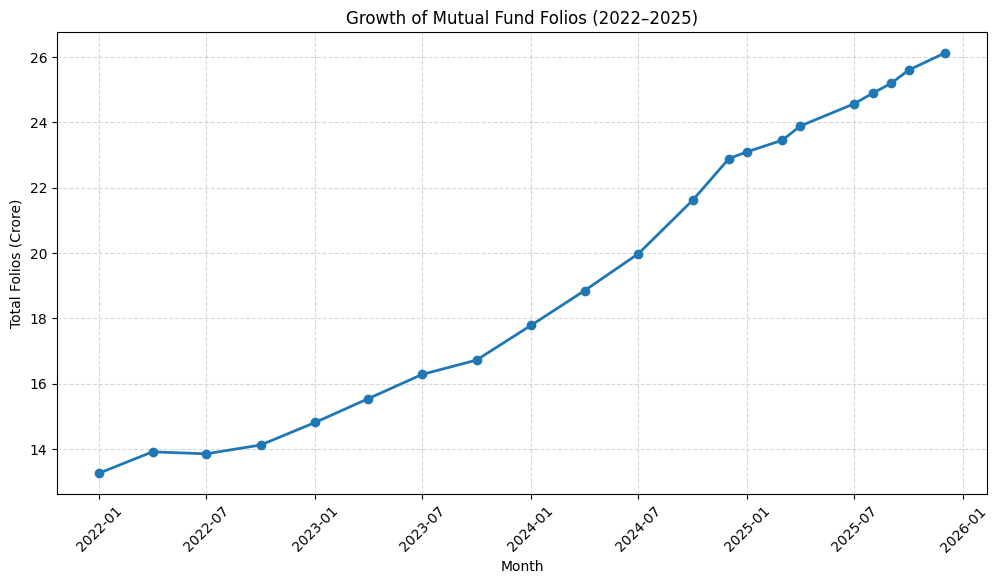

In [31]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth of Mutual Fund Folios (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.5)

Text(-60, 15, '26.12 Cr')

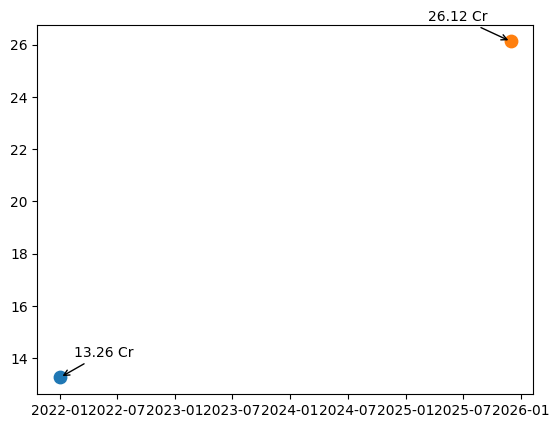

In [32]:
start = folio.iloc[0]
end = folio.iloc[-1]

plt.scatter(start["month"], start["total_folios_crore"], s=80)
plt.scatter(end["month"], end["total_folios_crore"], s=80)

plt.annotate(
    f'{start["total_folios_crore"]:.2f} Cr',
    (start["month"], start["total_folios_crore"]),
    xytext=(10,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f'{end["total_folios_crore"]:.2f} Cr',
    (end["month"], end["total_folios_crore"]),
    xytext=(-60,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

In [ ]:
plt.tight_layout()

plt.savefig(
    "../charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [34]:
import os

print(os.path.exists("../charts/folio_growth.png"))

True


### Chart 7: Growth of Mutual Fund Folios (2022–2025)

**Objective**

Analyze the growth in the number of mutual fund folios over time.

**Business Insight**

The total number of mutual fund folios increased steadily throughout the analysis period, demonstrating sustained growth in retail investor participation. The upward trend reflects increasing awareness and adoption of mutual fund investments.

In [35]:
nav["date"] = pd.to_datetime(nav["date"])

nav_merged = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [36]:
selected_funds = nav_merged["scheme_name"].unique()[:10]

selected_funds

array(['HDFC Top 100 Fund - Regular Plan - Growth',
       'HDFC Short Term Debt Fund - Regular - Growth',
       'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
       'ABSL Frontline Equity Fund - Regular - Growth',
       'ABSL Small Cap Fund - Regular - Growth',
       'ABSL Liquid Fund - Regular - Growth',
       'UTI Nifty 50 Index Fund - Regular - Growth',
       'UTI Mid Cap Fund - Regular - Growth',
       'UTI Flexi Cap Fund - Regular - Growth',
       'Nippon India Large Cap Fund - Regular - Growth'], dtype=object)

In [37]:
nav_pivot = nav_selected.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

nav_pivot.head()

NameError: name 'nav_selected' is not defined

In [38]:
nav["date"] = pd.to_datetime(nav["date"])

nav_merged = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_merged.shape)

(46000, 4)


In [39]:
selected_funds = nav_merged["scheme_name"].unique()[:10]

print(selected_funds)

['HDFC Top 100 Fund - Regular Plan - Growth'
 'HDFC Short Term Debt Fund - Regular - Growth'
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth'
 'ABSL Frontline Equity Fund - Regular - Growth'
 'ABSL Small Cap Fund - Regular - Growth'
 'ABSL Liquid Fund - Regular - Growth'
 'UTI Nifty 50 Index Fund - Regular - Growth'
 'UTI Mid Cap Fund - Regular - Growth'
 'UTI Flexi Cap Fund - Regular - Growth'
 'Nippon India Large Cap Fund - Regular - Growth']


In [40]:
nav_selected = nav_merged[
    nav_merged["scheme_name"].isin(selected_funds)
]

print(nav_selected.shape)

(11500, 4)


In [41]:
nav_pivot = nav_selected.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

nav_pivot.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,107.3758,26.3169,520.4608,42.8339,191.0721,119.2905,89.8728
2022-01-04,305.4514,310.6977,38.1545,105.9447,26.2234,515.0971,42.8033,189.0737,120.6402,90.8724
2022-01-05,306.6324,310.8165,38.1775,105.4800,26.2221,521.7239,43.0564,188.0701,121.4580,90.1565
2022-01-06,305.9800,310.7719,37.0665,104.9350,26.1728,515.7880,43.2088,190.4545,125.2386,91.5338
2022-01-07,304.0480,310.8388,37.9845,104.3318,26.2261,515.1639,42.9585,187.3124,124.1321,90.6762


In [42]:
daily_returns = nav_pivot.pct_change().dropna()

daily_returns.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-04,0.001153,-0.000141,-0.010865,-0.013328,-0.003553,-0.010306,-0.000714,-0.010459,0.011314,0.011122
2022-01-05,0.003866,0.000382,0.000603,-0.004386,-0.000050,0.012865,0.005913,-0.005308,0.006779,-0.007878
2022-01-06,-0.002128,-0.000143,-0.029101,-0.005167,-0.001880,-0.011377,0.003540,0.012678,0.031127,0.015277
2022-01-07,-0.006314,0.000215,0.024766,-0.005748,0.002036,-0.001210,-0.005793,-0.016498,-0.008835,-0.009369
2022-01-10,0.011548,0.000690,0.001251,0.006277,0.006791,-0.008639,0.006360,-0.011593,-0.000722,-0.001202


In [43]:
corr_matrix = daily_returns.corr()

corr_matrix

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,-0.018079,0.023769,0.027747,-0.005432,-0.006490,0.007229,0.001570
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,0.007864,0.018455,-0.033773,0.003507,0.036547,0.014307,-0.001436
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.000351,-0.006710,0.016053,0.043384,0.002304,0.004860,-0.005929
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.018079,0.007864,0.000351,1.000000,0.002150,-0.000006,-0.013318,-0.036647,-0.018166,-0.034228
HDFC Short Term Debt Fund - Regular - Growth,0.023769,0.018455,-0.006710,0.002150,1.000000,0.045567,-0.014166,-0.005648,0.013754,-0.001038
HDFC Top 100 Fund - Regular Plan - Growth,0.027747,-0.033773,0.016053,-0.000006,0.045567,1.000000,-0.026781,-0.023316,-0.005867,-0.093533
Nippon India Large Cap Fund - Regular - Growth,-0.005432,0.003507,0.043384,-0.013318,-0.014166,-0.026781,1.000000,0.001248,-0.039886,-0.000285
UTI Flexi Cap Fund - Regular - Growth,-0.006490,0.036547,0.002304,-0.036647,-0.005648,-0.023316,0.001248,1.000000,-0.007865,-0.036704
UTI Mid Cap Fund - Regular - Growth,0.007229,0.014307,0.004860,-0.018166,0.013754,-0.005867,-0.039886,-0.007865,1.000000,0.020691


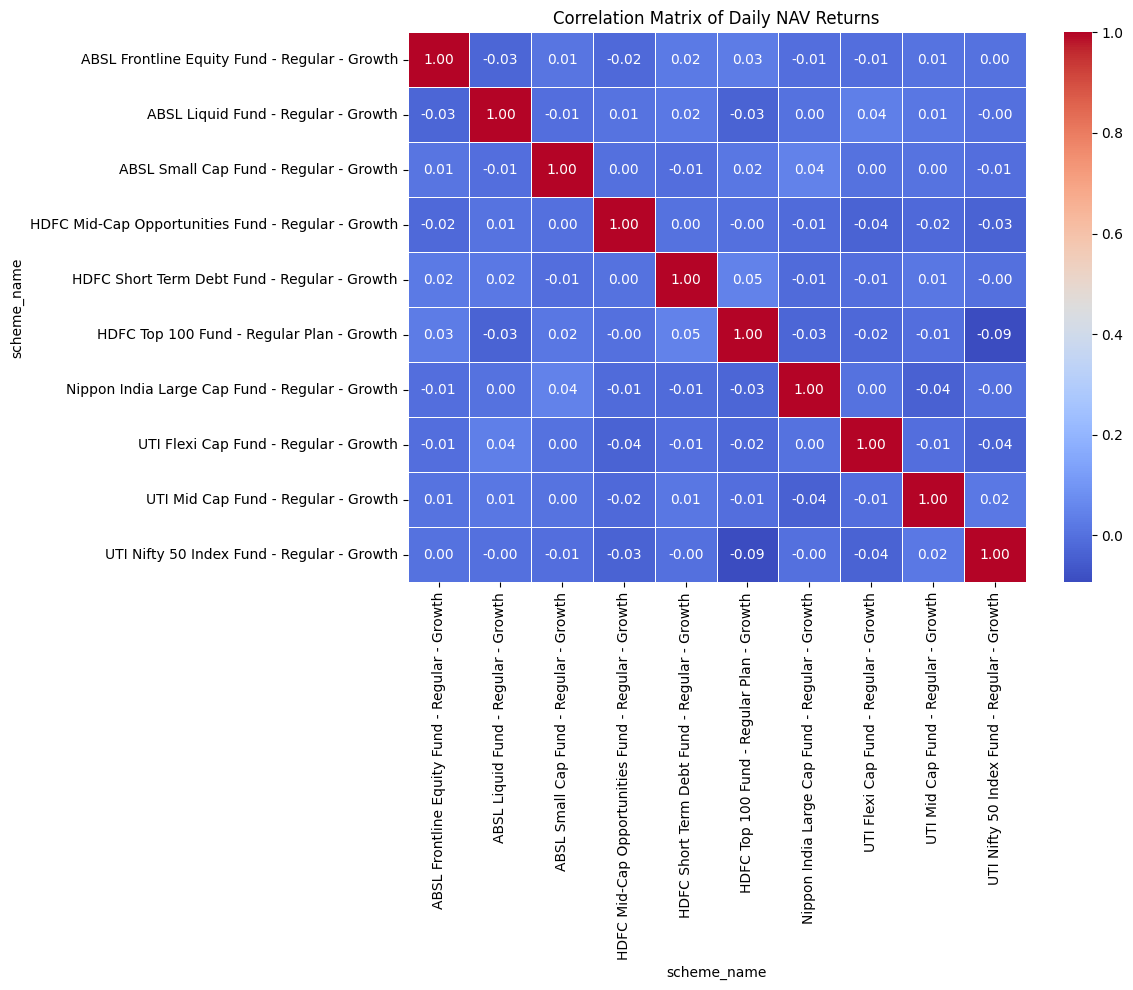

In [44]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 8: NAV Return Correlation Matrix

**Objective**

Analyze the correlation between daily returns of selected mutual fund schemes.

**Business Insight**

Most selected mutual funds show positive correlations, indicating that they tend to move in similar directions due to overall market trends. However, differences in correlation values suggest that diversification across schemes can still help reduce portfolio risk.

In [45]:
holding.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [46]:
print(holding.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [47]:
holding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [48]:
sector_weights = (
    holding.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

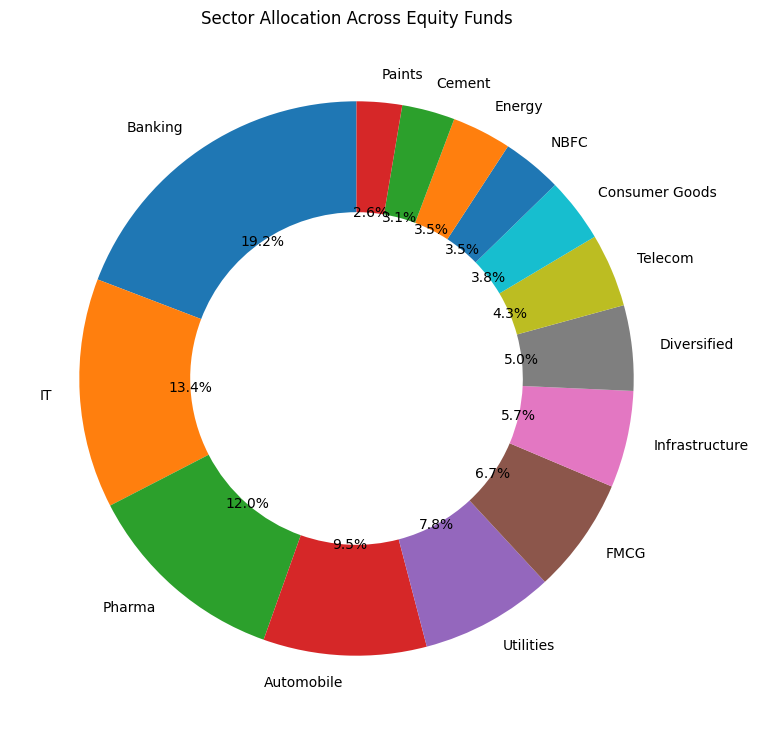

In [49]:
plt.figure(figsize=(9,9))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    "../charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Chart 9: Sector Allocation Across Equity Funds

**Objective**

Analyze the overall sector allocation across all equity mutual fund portfolios.

**Business Insight**

The sector allocation chart highlights the concentration of investments across different industries. Sectors with larger weights represent the primary focus of equity fund investments, while smaller sectors contribute to portfolio diversification.

# Key Exploratory Data Analysis (EDA) Findings

1. Daily NAV values generally showed an upward trend across most mutual fund schemes from 2022 to 2026, indicating long-term growth despite short-term fluctuations.

2. SBI Mutual Fund recorded the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore in 2025.

3. Monthly SIP inflows increased steadily over the analysis period and reached an all-time high of ₹31,002 crore in December 2025.

4. Liquid Funds consistently attracted the highest net inflows among fund categories, while ELSS and Gilt funds had comparatively lower inflows.

5. The 26–35 age group represented the largest investor segment (about 41%), showing strong participation from young working professionals.

6. Investment amounts varied across all age groups, with several high-value outliers observed in every category.

7. Male investors accounted for approximately two-thirds of the investor base, indicating higher participation than female investors.

8. Investors from T30 cities contributed around two-thirds of total participation, though B30 cities also showed meaningful investment activity.

9. Total mutual fund folios increased steadily throughout the analysis period, reflecting sustained growth in retail investor participation.

10. Banking, IT, and Pharma were the dominant sectors in equity fund portfolios, indicating a concentration in financial services and technology while maintaining diversification across other industries.